## Proyecto 02_Modelado cinético y balance de materia. Metanólisis de amina-borano catalizada por nanopartículas M·NHC (M = Fe, Co, Ni)

**Introducción:**

La amina-borano (H₃N·BH₃) es un sólido rico en hidrógeno, propuesto como material de
almacenamiento químico de H₂. Puede sintetizarse mediante una reacción entre borohidruro de sodio y una sal de amonio, típicamente en un disolvente etéreo (como THF) con calentamiento suave (40-45 °C):

$$NaBH_4 + NH_4Cl \xrightarrow{THF,\ \Delta} H_3N{\cdot}BH_3 + NaCl + H_2$$

Este notebook de jupyter supone una continuación directa de un proyecto anterior, el **Proyecto 01**, que está centrado en la visualización de datos correspondientes a procesos de metanólisis de amina-borano catalizados por una serie de seis nanomateriales diferentes. La reacción general que se está estudiando puede expresarse como: 

$$H_3N{\cdot}BH_3 + 4\,CH_3OH \xrightarrow{\text{catalizador}} NH_4B(OCH_3)_4 + 3\,H_2$$

Los catalizadores empleados consisten en sistemas que están basados en nanopartículas de Fe, Co o Ni; sintetizados mediante el método organometálico y empleando un carbeno, **IMes** o **IPr** como agente estabilizante: 

<center>
    <img src="Sintesis_nps.png" alt="Sintesis" width="50%">
</center>


En este **Proyecto 02** nos vamos a centrar en construir un balance de materia sencillo, a partir de los datos en bruto recogidos por un sensor de presión USB que conecta el reactor con un ordenador. Posteriormente, se ajustará una ley cinética, modelaremos los datos y se utilizará dicho modelo para predecir nuevos procesos. Los datos empleados en este notebook se corresponden con los publicados en el capítulo IV de la siguiente tesis doctoral: https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b. Si se desea obtener más información, se adjunta bibliografía recomendada en la parte final.      

In [1]:
import pandas as pd #Importamos pandas y abreviamos como pd, lo estándar
import numpy as np  #Importamos numpy y abreviamos como np, lo estándar
import matplotlib.pyplot as plt #Importamos matplotlib y abreviamos como plt, ídem con lo anterior
from scipy.optimize import curve_fit 

archivo = "Datos_bruto.xlsx" #Cargamos el fichero
df_crudo = pd.read_excel(archivo, sheet_name="CoIMES0.2") #Seleccionamos la hoja de excel y la convertimos en un df de pandas
print(df_crudo.columns.tolist()) #Observamos las columnas de las que consta el excel, según las lee pandas
print(df_crudo.head()) #Veamos las primeras entradas del df

['Time / s', 'Pressure / bar', 'Temperature / °C', 'Unnamed: 3', 't (s)', 't(min)', 'Δn H2 ', 'R (atm L)', 'T (K)', 'V (mL)', 'ΔP (bar)', 'Unnamed: 11', 'nH2/nNH3BH3', 'Unnamed: 13', 'normal', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'n NH3BH3']
    Time / s  Pressure / bar  Temperature / °C  Unnamed: 3      t (s)  \
0   0.030000        1.290086         26.048375         NaN   0.000000   
1   0.230000        1.290047         26.041096         NaN   0.200000   
2   5.230007        1.291135         26.034357         NaN   5.200007   
3  10.230014        1.291309         26.030313         NaN  10.200014   
4  15.230021        1.288904         26.014410         NaN  15.200021   

     t(min)    Δn H2   R (atm L)  T (K)  V (mL)  ΔP (bar)  Unnamed: 11  \
0  0.000000  0.000000      0.082  303.0    27.5       NaN          0.0   
1  0.003333 -0.000042        NaN    NaN     NaN -0.000038          NaN   
2  0.086667  0.001162        NaN    NaN     NaN  0.001050          NaN   


Varias observaciones respecto al df de la celda anterior:
1. En el reactor cerrado donde se realiza el proceso catalítico, la presión medida por el sensor va referida a presión total del sistema, no particularmente a la presión de hidrógeno generado. El indicador real del producto generado es el incremento de la presión total del sistema, ΔP. Dicho incremento, junto con la ecuación de los gases ideales (P V = n R T) y las variables implicadas, nos dará los moles de hidrógeno generados. 
2. La presión está medida en bar, sin embargo se utiliza el valor de la constante de los gases R se da como 0.082 atm L. Si se utiliza tal cual, supondría un error, pequeño a nivel matemático pero importante a nivel conceptual, ya que 1 bar = 0.9869 atm.
3. El volumen del reactor está en mL, y aparece como un valor fijo en una única celda, hay que extraerlo como valor suelto.
4. El sensor registra oscilaciones de temperatura en torno a 26 ºC, valor numérico que no se corresponde con la celda única en la que se registra una temperatura de 303 K (26 ºC = 299 K). Esa diferencia se debe a las condiciones experimentales en las que se operó: la temperatura del reactor estaba controlada externamente por un termostato (marcando 303 K) pero el sensor USB registraba la temperatura de manera independiente, de ahí las oscilaciones térmicas registradas. Usemos el valor fijado por termostato, más adecuado para medir temperatura que el sensor de presión USB.
5. La columna que lleva por nombre n NH3BH3 hace referencia al número de moles de sustrato empleados, aunque no tiene unidad asignada. Si consultamos los datos de la sección 4.3.5 de la tesis previamente citada, se hace referencia al procedimiento experimental: **"A freshly prepared solution of AB (1.9 M) in MeOH (1 mL, 1.9 mmol H3N·BH3)"**. Ese valor de 1.9 mmol coincide con los datos del excel. Confirmamos que las unidades de la columna del df que nos interesa son mmol.
6. Las columnas Δn H2, ΔP (bar) y nH2/nNH3BH3 se corresponde con cálculos realizados en el excel original para determinar los valores de moles de hidrógeno generados, deferencia de presión y cociente entre moles de sustrato y de producto. Vamos a descartarlas, para este proyecto nos interesa realizar ese balance en Python, haciendo los cálculos desde cero. 

In [2]:
volumen = df_crudo["V (mL)"].dropna().iloc[0] / 1000   # Retiramos los valores NaN de la columna de volumen y convertimos sus unidades de mL a L. Además, con iloc[0], una vez limpiada la columna, hacemos que se encadene el valor que queremos fijo. De otra forma, podría darnos el valor NaN en un momento dado.  
temperatura = df_crudo["T (K)"].dropna().iloc[0]         # Ídem con lo anterior, caso de la temperatura medida con el termostato
n_NH3BH3 = df_crudo["n NH3BH3"].dropna().iloc[0] / 1000  # Ídem con lo anterior, convertimos mmol en mol 
R = 0.08314  # bar·L/(mol·K)

print("Volumen (L):", volumen) #Imprimimos en pantalla los valores que vamos a utilizar para las variables P, V y N. 
print("Temperatura (K):", temperatura)
print("n NH3BH3 (mol):", n_NH3BH3)

Volumen (L): 0.0275
Temperatura (K): 303.0
n NH3BH3 (mol): 0.0019


In [3]:
P0 = df_crudo["Pressure / bar"].iloc[0] #Especificamos como presión inicial el primer dato registrado
df_crudo["ΔP_calculado"] = df_crudo["Pressure / bar"] - P0 #Calculamos el incremento de presión en cada punto registrado, a partir del dato de presión inicial y la presión medida en cada instante 
df_crudo["n_H2_calculado"] = (df_crudo["ΔP_calculado"] * volumen) / (R * temperatura) #Mediante la ecuación de los gases ideales, establecemos la relación n = (P*V)/(R*T) para determinar los moles de hidrógeno generados en cada instante
df_crudo["nH2/nNH3BH3_calculado"] = df_crudo["n_H2_calculado"] / n_NH3BH3 #Calculamos el cociente entre moles de hidrógeno y moles de sustrato utilizados. 

print(df_crudo[["t(min)", "nH2/nNH3BH3_calculado", "nH2/nNH3BH3"]].head(10)) #Observemos los primeros puntos del df y comparamos los valores de nH2/nNH3BH3_calculado aquí con Python con los de nH2/nNH3BH3, que se encontraban en el excel original, pero que presentaban el error de utilizar 0.082 atm·L en lugar de R = 0.08314  bar·L/(mol·K) 

     t(min)  nH2/nNH3BH3_calculado  nH2/nNH3BH3
0  0.000000               0.000000     0.000000
1  0.003333              -0.000022    -0.000022
2  0.086667               0.000603     0.000612
3  0.170000               0.000703     0.000713
4  0.253334              -0.000679    -0.000688
5  0.336667               0.001636     0.001659
6  0.420001               0.007516     0.007621
7  0.503334               0.007034     0.007131
8  0.586667               0.012651     0.012827
9  0.670001               0.014133     0.014330


Al comparar nH2/nNH3BH3_calculado con nH2/nNH3BH3, podemos observar que los datos siguen la misma tendencia, aunque con los valores ligeramente ajustados por usar R = 0.08314  bar·L/(mol·K). Podemos dar por correcto el cálculo de nH2/nNH3BH3_calculado. En la celda siguiente debemos introducir el factor de normalización, al igual que ya se realizó en el proyecto **Proyecto 01**. Teniendo en cuenta que el valor máximo del hidrógeno generado es de 3 mol de hidrógeno por mol de amina-borano:   

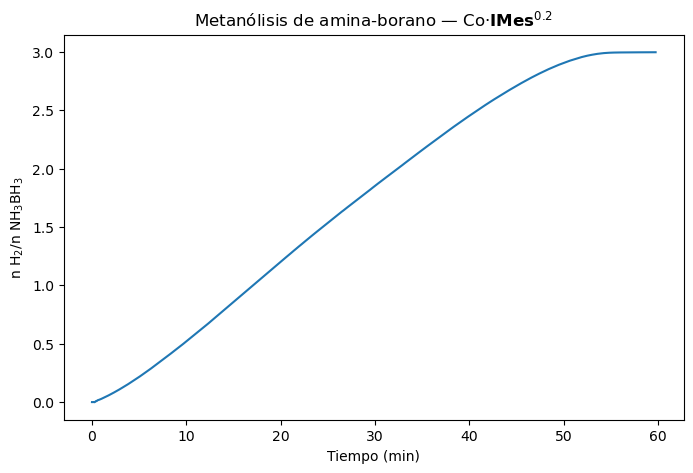

In [4]:
factor_normalizacion = 3.0 / df_crudo["nH2/nNH3BH3_calculado"].max() #Estableciendo el máximo en 3, el factor de normalización será el cociente 3/(nH2/nNH3BH3_calculado)
df_crudo["nH2/nNH3BH3_norm"] = df_crudo["nH2/nNH3BH3_calculado"] * factor_normalizacion #Normalizamos cada valor de nH2/nNH3BH3_calculado

plt.figure(figsize=(8, 5)) #Ajustamos la gráfica a representar
plt.plot(df_crudo["t(min)"], df_crudo["nH2/nNH3BH3_norm"])
plt.xlabel("Tiempo (min)") #Titulamos el eje x
plt.ylabel(r"n H$_2$/n NH$_3$BH$_3$") #Titulamos el eje y
plt.title(r"Metanólisis de amina-borano — Co·$\mathbf{IMes}^{0.2}$") #Titulamos el gráfico
plt.show() #Observamos la representación

Esta curva muestra un comportamiento análogo al encontrado en el **Proyecto 01**, aunque realizando el ajuste del balance de materia in situ con python y corrigiendo pequeños desajustes. El estudio del mecanismo real de la reacción sería bastante complejo, ya que presenta varios reactivos (amina-borano y metanol) y un catalizador coloidal, con la dificultad añadida que eso puede entrañar. Sin embargo, el diseño experimental del proceso (usando metanol como disolvente) permite tratar a la reacción como si fuera de pseudo-primer orden respecto al amina-borano. En este caso, la velocidad de la reacción podría expresarse como sigue: 

$$H_3N{\cdot}BH_3 + 4\,CH_3OH \xrightarrow{\text{catalizador}} NH_4B(OCH_3)_4 + 3\,H_2$$
$$
\begin{aligned}
v &= k\,[NH_3BH_3]^{\alpha}\,[CH_3OH]^{\beta} \approx k_{obs}\,[NH_3BH_3]^{\alpha} \\
k_{obs} &= k \cdot [CH_3OH]_0^{\beta}
\end{aligned}
$$

Recordemos las expresiones para ecuaciones cinética sencillas, de orden 0, de orden 1 o de orden 2:

| Orden ($n$) | Ley diferencial | Forma integrada $[A](t)$ | Forma linealizada | $t_{1/2}$ |
|---|---|---|---|---|
| 0 | $-\frac{d[A]}{dt} = k$ | $[A] = [A]_0 - kt$ | ídem | $\frac{[A]_0}{2k}$ |
| 1 | $-\frac{d[A]}{dt} = k[A]$ | $[A] = [A]_0 e^{-kt}$ | $\ln[A] = \ln[A]_0 - kt$ | $\frac{\ln 2}{k}$ |
| 2 | $-\frac{d[A]}{dt} = k[A]^2$ | $[A] = \frac{[A]_0}{1+k[A]_0 t}$ | $\frac{1}{[A]} = \frac{1}{[A]_0} + kt$ | $\frac{1}{k[A]_0}$ |

Observando la gráfica anterior, se tiene una reacción que avanza rápidamente en su comienzo y se aplana progresivamente en su parte final. Este comportamiento permite descartar una cinética de orden 0, si bien aún no sabemos si al expresar la velocidad de la reacción ($v = k_{\text{obs}} [\text{NH}_3\text{BH}_3]^\alpha$), tendríamos  α=1 o α=2. Sin embargo, antes de utilizar las leyes de velocidad de orden 1 o 2, existe un problema. No tenemos una medida directa de $[\text{NH}_3\text{BH}_3]$, sino que traducimos la presión generada en el sistema a moles de hidrógeno gaseoso, que luego relacionamos con moles de amina-borano. Las leyes de velocidad nos están hablando de cuánto reactivo queda, pero nuestro instrumental nos está especificando cuánto producto se ha formado. Debemos relacionar ambos factores, por lo que definimos el grado de conversión como:

$$X(t) = 1 - \frac{[A]}{[A]_0}$$

Y dado que $n_{max}$ representa la conversión completa ($n_{max}$=3 equivalentes de H₂ por mol de amina-borano), la magnitud medida experimentalmente se relaciona con $X(t)$ mediante:

$$\frac{n_{H_2}}{n_{NH_3BH_3}}(t) = n_{max} \cdot X(t)$$

Por lo tanto, las expresiones que vamos a utilizar quedarían como: 



| Orden ($n$) | $[A](t)$ | $X(t) = 1-[A]/[A]_0$ | $\dfrac{n_{H_2}}{n_{NH_3BH_3}}(t) = n_{max}\cdot X(t)$ |
|---|---|---|---|
| 0 | $[A]_0 - k_0\,t$ | $\dfrac{k_0}{[A]_0}\,t$ | $n_{max}\cdot k_0\,t$ |
| 1 | $[A]_0\,e^{-k_1 t}$ | $1-e^{-k_1 t}$ | $n_{max}\,(1-e^{-k_1 t})$ |
| 2 | $\dfrac{[A]_0}{1+k_2[A]_0\,t}$ | $\dfrac{k_2[A]_0\,t}{1+k_2[A]_0\,t}$ | $n_{max}\,\dfrac{k_2\,t}{1+k_2\,t}$ |

Ahora estamos listos para definir las funciones modelo de orden 1 y orden 2, y comprobar cómo se ajustan nuestros datos a las mismas: 


In [5]:
def modelo_orden1(t, n_max, k1):
    return n_max * (1 - np.exp(-k1 * t)) #Introducimos la expresión de la cuarta columna de la tabla anterior para modelar la cinética de primer orden

def modelo_orden2(t, n_max, k2):
    return n_max * (k2 * t) / (1 + k2 * t) #Introducimos la expresión de la cuarta columna de la tabla anterior para modelar la cinética de segundo orden

In [6]:
from scipy.optimize import curve_fit

t_datos = df_crudo["t(min)"] #Asignamos valores de tiempo a t_datos
y_datos = df_crudo["nH2/nNH3BH3_norm"] #Asignamos valores de equivalentes de hidrógeno generados a y_datos

popt1, pcov1 = curve_fit(modelo_orden1, t_datos, y_datos, p0=[3, 0.05]) #A diferencia de una regresión lineal, aquí pasamos la función matemática que quiero ajustar, que hemos llamado modelo_orden1. Así, con curve_fit encontramos los parámetros que mejor la hacen coincidir con mis datos
popt2, pcov2 = curve_fit(modelo_orden2, t_datos, y_datos, p0=[3, 0.05]) #Ídem, con la función que hemos definido como modelo_orden2

print("Orden 1 -> n_max:", popt1[0], " k1:", popt1[1]) #Imprimimos el resultado del ajuste para orden 1
print("Orden 2 -> n_max:", popt2[0], " k2:", popt2[1]) #Imprimimos el resultado del ajuste para orden 2

Orden 1 -> n_max: 3.0  k1: 0.05
Orden 2 -> n_max: 3.0  k2: 0.05


C:\Users\Pablo\AppData\Local\Temp\ipykernel_22028\716944428.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt1, pcov1 = curve_fit(modelo_orden1, t_datos, y_datos, p0=[3, 0.05]) #A diferencia de una regresión lineal, aquí pasamos la función matemática que quiero ajustar, que hemos llamado modelo_orden1. Así, con curve_fit encontramos los parámetros que mejor la hacen coincidir con mis datos
C:\Users\Pablo\AppData\Local\Temp\ipykernel_22028\716944428.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt2, pcov2 = curve_fit(modelo_orden2, t_datos, y_datos, p0=[3, 0.05]) #Ídem, con la función que hemos definido como modelo_orden2


El ajuste anterior ha arrojado unos valores que no tienen mucho sentido, un mismo valor para k1 y k2. A priori, cabe esperar que el ajuste fuera más apropiado para un orden de reacción u otro, pero k1=0.05=k2 chirría mucho; y más cuando en p0 hemos introducido [3, 0.05]. Nos ha devuelvo exactamente los mismos valores establecidos ¿Me he equivocado al darle parámetros al optimizador? Vamos a ver si es un problema de los datos: 

In [7]:
print(t_datos.shape, y_datos.shape)
print(t_datos.head())
print(y_datos.head())
print(y_datos.isna().sum())
print(t_datos.dtype, y_datos.dtype)

(779,) (779,)
0    0.000000
1    0.003333
2    0.086667
3    0.170000
4    0.253334
Name: t(min), dtype: float64
0    0.000000
1   -0.000027
2    0.000753
3    0.000878
4   -0.000848
Name: nH2/nNH3BH3_norm, dtype: float64
0
float64 float64


Los datos parecen limpios: 779 filas, no parece que haya huecos NaN, los nombres t(min) y nH2/nNH3BH3_norm son los que esperamos, y los tipos de datos también (float). Los datos no son el problema, o no lo parecen a priori. ¿Cambiamos los df de pandas a arrays de Numpy? Tal vez eso soluciona el problema.

#### Nota: Depuración de errores. 
"""Si esta celda se cambia a de markdown a code y se ejecutase, devuelve mensaje de error en xdata. 
Es decir, en este punto inicialmente había algún problema con la variable de tiempo que no se había detectado antes. 
Una de dos, o hay un valor NaN en algún sitio, o hay algún valor infinito. En la celda siguiente, 
se lanzan cuatro líneas para detectar dos tipos de datos rotos, en las columnas de tiempo y de equivalentes de hidrógeno,
que permitieron resolver el error. Se recomienda mantener esta celda como markwon, a efectos de narrativa del notebook,
pero sin entorpecer una ejecución con *Restart the kernel and run all cells*""" 

t_arr = t_datos.to_numpy()
y_arr = y_datos.to_numpy()

popt1, pcov1 = curve_fit(modelo_orden1, t_arr, y_arr, p0=[3, 0.05])
popt2, pcov2 = curve_fit(modelo_orden2, t_arr, y_arr, p0=[3, 0.05])
print(popt1)
print(popt2)

In [8]:
print("NaN en t:", t_datos.isna().sum()) #Recorremos la columna de tiempo, devuelve True si está vacía (NaN, "Not a number" o False si tiene un valor numérico. Con .sum()) hacemos que Python considere True como 1 y False como 0, así que en conjunto nos va a decir cuántos huecos hay.  
print("Inf en t:", np.isinf(t_datos).sum()) #Recorremos la columna de tiempo, devuelve True si es valor "infinito". Con .sum()) hacemos que Python considere True como 1 y False como 0, así que en conjunto nos va a decir cuántos huecos hay.
print("NaN en y:", y_datos.isna().sum()) #Recorremos la columna de equivalentes de hidrógeno para ver si hay huecos NaN, ídem a la de tiempo
print("Inf en y:", np.isinf(y_datos).sum()) #Recorremos la columna de equivalentes de hidrógeno para ver si hay valores "infinitos", ídem a la de tiempo

NaN en t: 60
Inf en t: 0
NaN en y: 0
Inf en y: 0


Vale, parece que ya estamos localizando qué ocurre. Hay 60 huecos NaN en la columna de tiempo.  

In [9]:
filas_con_huecos_NaN = df_crudo[df_crudo["t(min)"].isna()]
print(filas_con_huecos_NaN[["Time / s", "Pressure / bar", "Temperature / °C", "t (s)", "t(min)"]]) #Vamos a comprobar si los huecos NaN están en las dos columnas de tiempo (min o s) o sólo en una

      Time / s  Pressure / bar  Temperature / °C      t (s)  t(min)
719  3590.2350        5.463930         25.674501  3590.2050     NaN
720  3595.2350        5.463971         25.676385  3595.2050     NaN
721  3600.2350        5.464171         25.671541  3600.2050     NaN
722  3605.2350        5.463952         25.674501  3605.2050     NaN
723  3610.2351        5.464065         25.671810  3610.2051     NaN
724  3615.2351        5.463978         25.683652  3615.2051     NaN
725  3620.2351        5.464247         25.680422  3620.2051     NaN
726  3625.2351        5.464320         25.674501  3625.2051     NaN
727  3630.2351        5.464319         25.686075  3630.2051     NaN
728  3635.2351        5.464294         25.681230  3635.2051     NaN
729  3640.2351        5.464399         25.680961  3640.2051     NaN
730  3645.2351        5.464372         25.677193  3645.2051     NaN
731  3650.2351        5.464560         25.676924  3650.2051     NaN
732  3655.2351        5.464869         25.678000

Vale, problema detectado. Los huecos sólo están entre las filas 719 y 778, para la variable t(min). No es un problema del sensor de la reacción química, que sí que tomó datos hasta el final (Time/s); es un problema del excel original, donde sólo se hizo la conversión de s a min hasta la fila 719. Vamos a recalcular t(min) a partir de los datos reales. 

In [10]:
tiempo_inicial = df_crudo["Time / s"].iloc[0] #Tomamos el primer valor de la columna Time/s
df_crudo["t(min)_recalculado"] = (df_crudo["Time / s"] - tiempo_inicial) / 60  #Restamos el valor en cada punto al tiempo del instante inicial (simplemente para que t empiece en 0) y dividimos entre 60 para tener el valor en min en toda la columna. Lo asociamos a una nueva columna, "t(min)_recalculado", para diferenciar.  

print(df_crudo[["t(min)", "t(min)_recalculado"]].iloc[715:722]) #Imprimimos en pantalla un segmento que empiece desde antes del error (fila 715, antes de la 719) y muestre un poco después (fila 722, tras la 719), para la columna t(min) original y la t(min)_recalculado. 

        t(min)  t(min)_recalculado
715  59.503417           59.503417
716  59.586750           59.586750
717  59.670083           59.670083
718  59.753417           59.753417
719        NaN           59.836750
720        NaN           59.920083
721        NaN           60.003417


In [11]:
df_crudo["t(min)"] = df_crudo["t(min)_recalculado"] #Sobreescribimos los datos originales por los recalculamos
df_crudo = df_crudo.drop(columns=["t(min)_recalculado"]) #Dropeamos la columna ["t(min)_recalculado"], total, no nos sirve de nada tener dos columnas con la misma información en el df


In [12]:
t_datos = df_crudo["t(min)"].to_numpy() #Asignamos t(min), ya con los valores resuletos y nH2/nNH3BH3_norm a las variables t_datos e y_datos
y_datos = df_crudo["nH2/nNH3BH3_norm"].to_numpy()


print(t_datos.shape, y_datos.shape) #Veamos el numero de filas dentro de cada variable
print(np.isnan(t_datos).sum(), np.isnan(y_datos).sum()) #Comprobemos si hay huecos NaN

(779,) (779,)
0 0


Al fin podemos relanzar el ajuste, vamos a utilizar los datos ya corregidos. 

In [13]:
popt1, pcov1 = curve_fit(modelo_orden1, t_datos, y_datos, p0=[3, 0.05])
popt2, pcov2 = curve_fit(modelo_orden2, t_datos, y_datos, p0=[3, 0.05])

print("Orden 1 -> n_max:", popt1[0], " k1:", popt1[1])
print("Orden 2 -> n_max:", popt2[0], " k2:", popt2[1])

Orden 1 -> n_max: 6.363708204322075  k1: 0.01135778195065316
Orden 2 -> n_max: 11.443711764666286  k2: 0.0063451592849608635


Bueno, vamos por partes. En esta ocasión cada n_max es diferente, y cada k también. Es un avance. El problema de ese resultado es que nos ha dado un n_max>3, lo que no tiene sentido químico. Vamos a ver si efectivamente el máximo y el mínimo de los datos en y está en 3, para descartar problemas con los datos.  

In [14]:
print(y_datos.max(), y_datos.min())

3.0 -0.0008481308858950969


máximo 3.0, mínimo -0.0008; un valor negativo no tiene sentido químico, peeeero es tan cercano a 0 que podemos asociarlo a ruido del sensor de medida al comienzo de la reacción. Lo damos por bueno. Veamos si la solución puede ser ponerle límites al optimizador. Por ejemplo, 5, un margen generoso respecto a 3; aunque por debajo de los valores que nos han devuelto antes. 

In [15]:
popt1, pcov1 = curve_fit(modelo_orden1, t_datos, y_datos, p0=[3, 0.05], #Especificamos la función matemática, cinética de orden 1, los datos experimentales en los ejes X e Y, y el punto de partida de la optimización, p0=[3, 0.05] 
                          method='trf', bounds=([0, 0], [5, 1])) #Usamos method "trf" para especificar qué algoritmo utilizar. Por defecto se utilizaría method='lm', que es rápido; pero no acepta límites, pero como hemos señalado bounds=([0, 0], [5, 1]), no sería compatible.  
popt2, pcov2 = curve_fit(modelo_orden2, t_datos, y_datos, p0=[3, 0.05], #Ídem a lo anterior, con la función de cinética de orden 2
                          method='trf', bounds=([0, 0], [5, 1]))

print("Orden 1 -> n_max:", popt1[0], " k1:", popt1[1]) #Imprimimos cada resultado en pantalla
print("Orden 2 -> n_max:", popt2[0], " k2:", popt2[1])

Orden 1 -> n_max: 4.999999999999999  k1: 0.01578069069146272
Orden 2 -> n_max: 4.999999999999997  k2: 0.021643535089860177


Parece que la optimización se da de bruces contra el límite impuesto, n_max:5. Sigue sin tener sentido físico, pero da la impresión de que si no forzamos el límite a 3, va a seguir dándonos valores disparatados. Probemos definiendo el modelo de orden 1 y 2 con más especificidad, sabiendo que n_max=3 por la estequiometría de la reacción

In [16]:
def modelo_orden1_fijo(t, k1): #Definimos los nuevos casos para orden 1 y 2 respectivamente 
    return 3.0 * (1 - np.exp(-k1 * t)) #Fijamos el valor de 3.0

def modelo_orden2_fijo(t, k2): #Ídem a lo anterior
    return 3.0 * (k2 * t) / (1 + k2 * t)

popt1, pcov1 = curve_fit(modelo_orden1_fijo, t_datos, y_datos, p0=[0.05]) #Ya no tenemos que proponer límites para n_max, lo hemos fijado en 3 por cómo se define modelo_orden1_fijo 
popt2, pcov2 = curve_fit(modelo_orden2_fijo, t_datos, y_datos, p0=[0.05]) #Ídem con modelo_orden2_fijo

print("Orden 1 -> k1:", popt1[0])
print("Orden 2 -> k2:", popt2[0])

Orden 1 -> k1: 0.0358383238547094
Orden 2 -> k2: 0.06128180860330064


Vale, con estos valores de k1 y k2, vamos a comprobar lo buen ajuste que sería cada caso. 

In [17]:
def calcular_r2(y_real, y_pred): #Definimos una función que nos sirva para calcular el coeficiente de determinación de cada modelo. Utilizamos argumentos (y_real, y_pred) para comparar los datos reales con los datos predichos por cada modelo
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - y_real.mean()) ** 2)
    return 1 - ss_res / ss_tot

y_pred_orden1 = modelo_orden1_fijo(t_datos, *popt1)  #Asignamos a la variable y_pred_orden1 los resultados obtenidos por el modelo de orden 1, popt1, como se denominó a lo de la celda anterior
y_pred_orden2 = modelo_orden2_fijo(t_datos, *popt2)  #Ídem a lo anterior con y_pred_orden1

r2_orden1 = calcular_r2(y_datos, y_pred_orden1) #Aplicamos la función a cada caso. 
r2_orden2 = calcular_r2(y_datos, y_pred_orden2)

print("R² orden 1:", r2_orden1) #Imprimimos
print("R² orden 2:", r2_orden2)

R² orden 1: 0.9111301025330774
R² orden 2: 0.7676031006682693


Con los valores que hemos obtenido, claramente el modelo de orden 1 se ajusta mejor ($R^2$=0.91) que el de orden 2 ($R^2$=0.76). Antes de dar por bueno el modelo, vamos a realizar una validación extra. Si el tiempo de semireacción observado en nuestros datos reales (es decir, cuando sabemos que se han generado 1.5 equiv.) está en el rango del tiempo de semireacción correspondiente a un k1=0.0358383238547094 (dado por el modelo), podríamos dar el modelo por bueno. 

In [18]:
idx_semireaccion = (df_crudo["nH2/nNH3BH3_norm"] - 1.5).abs().idxmin() #Esta línea es un poco engorrosa. Como el máximo son 3 equiv., le restamos la mitad, 1.5 equiv., a toda la columna, y toma el valor absoluto del resultado. El mínimo de la serie resultante, será el valor más cercano a 1.5 equiv. Con idxmin(), nos da el índice de la fila donde está ese mínimo, e ir a buscar el t(min) correspondiente a esa fila, que será nuestro t1/2 real
t_semireaccion_real = df_crudo.loc[idx_semireaccion, "t(min)"] #Asignamos el valor de t(min) correspondiente a idx_semireaccion a la variable t_semireaccion_real

t_semireaccion_modelo = np.log(2) / popt1[0] # Hacemos el cálculo ln 2/k1, que se corresponde con popt1[0], para calcular el t1/2 predicho por el modelo

print("t1/2 según los datos reales (minuto más cercano a 1.5 equiv.):", t_semireaccion_real)
print("t1/2 predicho por el modelo (ln2/k1):", t_semireaccion_modelo)
print("La diferencia encontrada es de", t_semireaccion_real-t_semireaccion_modelo, "min") #Obtenemos la diferencia entre ambos

t1/2 según los datos reales (minuto más cercano a 1.5 equiv.): 24.420034998333332
t1/2 predicho por el modelo (ln2/k1): 19.340948627229423
La diferencia encontrada es de 5.079086371103909 min


Bueno, la diferencia encontrada, 5.1 min, es coherente con un valor de ($R^2$=0.91). El modelo predice que el tiempo de semireacción se alcanzaría 5 minutos algo antes de lo que en realidad ocurre, lo que para una reacción que alcanza su punto máximo en torno a 60 minutos, es aceptable. Habiendo comprobado que el modelo nos arroja resultados coherentes, vamos a extenderlo a todos los catalizadores. Comencemos por definir dos funciones: una que calcule el balance de materia, y otra que realice un ajuste a un modelo correspondiente a una cinética de orden 1. 

In [19]:
def calcular_balance_materia(nombre_hoja, archivo): #Definimos una función para calcular el balance de materia en general
    df_hoja = pd.read_excel(archivo, sheet_name=nombre_hoja)

    volumen = df_hoja["V (mL)"].dropna().iloc[0] / 1000
    temperatura = df_hoja["T (K)"].dropna().iloc[0]
    n_NH3BH3 = df_hoja["n NH3BH3"].dropna().iloc[0] / 1000
    R = 0.08314 #Recordemos, R = 0.08314 bar L/ K mol

    P0 = df_hoja["Pressure / bar"].iloc[0]
    df_hoja["ΔP_calculado"] = df_hoja["Pressure / bar"] - P0
    df_hoja["n_H2_calculado"] = (df_hoja["ΔP_calculado"] * volumen) / (R * temperatura)
    df_hoja["nH2/nNH3BH3_calculado"] = df_hoja["n_H2_calculado"] / n_NH3BH3

    factor_normalizacion = 3.0 / df_hoja["nH2/nNH3BH3_calculado"].max() #Así el factor normalización se puede determinar al margen del valor máximo exacto
    df_hoja["nH2/nNH3BH3_norm"] = df_hoja["nH2/nNH3BH3_calculado"] * factor_normalizacion

    tiempo_inicial = df_hoja["Time / s"].iloc[0]
    df_hoja["t(min)"] = (df_hoja["Time / s"] - tiempo_inicial) / 60 #Calculamos directamente el tiempo en minutos a partir de la medida del sensor

    return df_hoja


def ajustar_y_evaluar_orden1(t_datos, y_datos): #Hacemos los ajustes directamente con el modelo_orden1_fijo, con n_max=3 desde el principio
    popt, pcov = curve_fit(modelo_orden1_fijo, t_datos, y_datos, p0=[0.05])
    k1 = popt[0]
    y_pred = modelo_orden1_fijo(t_datos, k1)
    r2 = calcular_r2(y_datos, y_pred)
    return k1, r2

def ajustar_y_evaluar_orden2(t_datos, y_datos): #Hacemos los ajustes directamente con el modelo_orden2_fijo, con n_max=3 desde el principio
    popt, pcov = curve_fit(modelo_orden2_fijo, t_datos, y_datos, p0=[0.05])
    k2 = popt[0]
    y_pred = modelo_orden2_fijo(t_datos, k2)
    r2 = calcular_r2(y_datos, y_pred)
    return k2, r2

Ahora, utilizando las funciones así definidas, vamos a aplicarlas a cada uno de los seis catalizadores. 

#### *Nota sobre las unidades de $k_2$

Las constantes $k_2$ de los modelos de orden 2 se han ajustado sobre
la fracción de conversión normalizada (0 a 3 equivalentes), no sobre concentración molar real. Por lo tanto, se trata de constantes *aparentes*: $k_{2,aparente} = k_{2,real}\times[A]_0$. $k_{2,real}$ se obtiene dividiendo directamente entre $[A]_0$, sin necesidad de reajustar el modelo sobre datos en unidades molares. La constante $k_1$, al ser el coeficiente del término lineal, no necesita corrección: sus unidades (min⁻¹) son independientes de la escala de concentración usada, y su valor no cambia entre ambas parametrizaciones.

Con $[NH_3BH_3]_0 = 1.9 mol/L$ (disolución madre usada en los seis catalizadores), $k_{2,real}$ queda expresado en L·mol⁻¹·min⁻¹, comparable directamente con la bibliografía de cinética de segundo orden. Posteriormente en el notebook se realiza un ajuste diferente, a un modelo autocatalítico, donde también se hace referencia a una k2. En dicho caso, se deben realizar las mismas consideraciones que se mencionan en esta nota. Estas apreciaciones no afectan a los resultados de los ajustes del modelo aplicado en cada caso, pero sí son importantes de cara a cuestiones de cinética química conceptualmente hablando. 

In [20]:
A0_molar = 1.9  # mol/L
orden_por_actividad = ["CoIPr0.2", "CoIMES0.2", "FeIMes0.5", "FeIPr0.5", "NiIMes0.2", "NiIPr0.2"] #Indicamos los catalizadores en orden decreciente de actividad, de acuerdo a lo mostrado en el Proyecto 01
resultados = {}
for hoja in orden_por_actividad:
    df_hoja = calcular_balance_materia(hoja, archivo)
    t_datos_hoja = df_hoja["t(min)"].to_numpy()
    y_datos_hoja = df_hoja["nH2/nNH3BH3_norm"].to_numpy()

    k1, r2_orden1 = ajustar_y_evaluar_orden1(t_datos_hoja, y_datos_hoja)
    k2, r2_orden2 = ajustar_y_evaluar_orden2(t_datos_hoja, y_datos_hoja)

    resultados[hoja] = {"k1": k1, "R2_orden1": r2_orden1, "k2": k2, "R2_orden2": r2_orden2}
    resultados[hoja]["k2_real"] = resultados[hoja]["k2"] / A0_molar  # Ahora sí existe resultados[hoja]

    print(hoja, "| orden1: k1=", round(k1,4), "R²=", round(r2_orden1,3),
              " | orden2: k2=", round(k2,4), "R²=", round(r2_orden2,3),
              " | k2_real=", round(resultados[hoja]["k2_real"],4))

CoIPr0.2 | orden1: k1= 0.0423 R²= 0.893  | orden2: k2= 0.0712 R²= 0.747  | k2_real= 0.0375
CoIMES0.2 | orden1: k1= 0.0358 R²= 0.911  | orden2: k2= 0.0613 R²= 0.768  | k2_real= 0.0323
FeIMes0.5 | orden1: k1= 0.029 R²= 0.971  | orden2: k2= 0.0583 R²= 0.819  | k2_real= 0.0307
FeIPr0.5 | orden1: k1= 0.0275 R²= 0.99  | orden2: k2= 0.058 R²= 0.856  | k2_real= 0.0305
NiIMes0.2 | orden1: k1= 0.0104 R²= 0.868  | orden2: k2= 0.0179 R²= 0.715  | k2_real= 0.0094
NiIPr0.2 | orden1: k1= 0.0055 R²= 0.906  | orden2: k2= 0.0092 R²= 0.775  | k2_real= 0.0048


Cabe destacar que en todos los casos, la función propia de una cinética de orden 1 se ajusta mejor que la de orden 2. Un apunte importante sobre los resultados obtenidos para cada catalizador: los valores de k1 son coherentes con la actividad mostrada por cada uno de los catalizadores (**ver Proyecto 01**). Además, parece que en las condiciones experimentales, todas las reacciones se comportan como un proceso de pseudo-primer orden respecto a la concentración de sustrato, para los seis catalizadores. En la siguiente celda vamos a visualizar en un gráfico de barras de estos valores. 

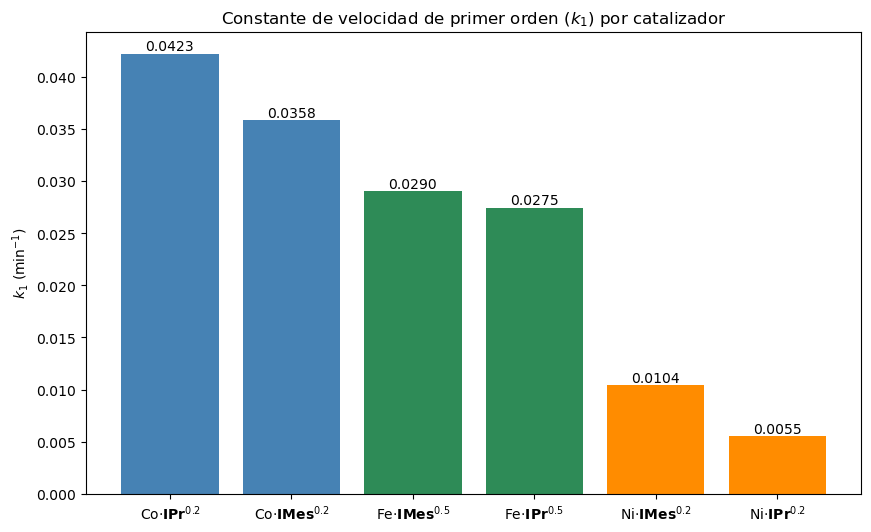

In [21]:
etiquetas_catalizadores = { #Le damos formato a las etiquetas de cada catalizador en el gráfico para seguir la notación química adecuada
    "CoIPr0.2":  r"Co·$\mathbf{IPr}^{0.2}$",
    "CoIMES0.2": r"Co·$\mathbf{IMes}^{0.2}$",
    "FeIMes0.5": r"Fe·$\mathbf{IMes}^{0.5}$",
    "FeIPr0.5":  r"Fe·$\mathbf{IPr}^{0.5}$",
    "NiIMes0.2": r"Ni·$\mathbf{IMes}^{0.2}$",
    "NiIPr0.2":  r"Ni·$\mathbf{IPr}^{0.2}$",
}

colores_por_metal = ["steelblue", "steelblue", "seagreen", "seagreen", "darkorange", "darkorange"] #Creamos una lista en la que agrupamos los metales por color

k1_valores = [resultados[cat]["k1"] for cat in orden_por_actividad]
etiquetas = [etiquetas_catalizadores[cat] for cat in orden_por_actividad]

plt.figure(figsize=(10, 6)) #Ajustamos tamaño de imagen
barras = plt.bar(etiquetas, k1_valores, color=colores_por_metal) 
plt.ylabel(r"$k_1$ (min$^{-1}$)") #Etiquetamos eje y con las unidades correctas
plt.title("Constante de velocidad de primer orden ($k_1$) por catalizador") #Titulamos el gráfico
plt.bar_label(barras, fmt='%.4f', fontsize=10) #Con fmt='%.4f' damos cuatro decimales, ya que son valores pequeños
plt.savefig("k1_seis_catalizadores.png", dpi=300, bbox_inches="tight")  #Guardamos localmente
plt.show() #Mostramos el gráfico

A continuación, vamos a construir una tabla en la que, utilizando $k_1$; muestre cuánto tiempo de reacción (t_X) es necesario para alcanzar un valor de conversión dado según nuestro modelo. Es decir, utilizando la ecuación de conversión para una cinética de primer orden:

$$\frac{n_{H_2}}{n_{max}}(t) = 1 - e^{-k_1 t}$$

Si denominamos $X$ al grado de conversión que queremos alcanzar (por ejemplo, $X=0.95$ para el 95%):

$$X = 1 - e^{-k_1 t}$$

Despejamos el término exponencial:

$$e^{-k_1 t} = 1 - X$$

Tomamos logaritmo neperiano en ambos lados:

$$-k_1 t = \ln(1-X)$$

Y despejamos $t$, que llamamos $t_X$ para indicar que es el tiempo necesario para alcanzar esa conversión $X$ concreta:

$$t_X = \frac{-\ln(1-X)}{k_1}$$

En la siguiente celda obtendremos dichos valores de t_X para X=0.9, X=0.95 y X=0.99

In [22]:
fracciones_objetivo = [0.90, 0.95, 0.99] #Creamos una lista con las fracciones objetivo

tiempos_conversion = {}
for hoja in orden_por_actividad: #Indicamos los catalizadores en orden decreciente de actividad
    k1 = resultados[hoja]["k1"] #Utilizamos los valores de k1 correspondientes al diccionario resultados
    tiempos_conversion[hoja] = {
        f"t_{int(f*100)}": -np.log(1 - f) / k1 for f in fracciones_objetivo #Por cada fracción de la lista, creamos una entrada con un nombre descriptivo para cada t
    }

tabla_tiempos_conversion = pd.DataFrame(tiempos_conversion).T #A priori, al generar el df de pandas a partir del diccionario tiempos_conversion, se pondrían los catalizadores como columnas y los tiempos como filas. Es más cómodo de leer al revés. Ponemos el .T para trasponer dicha orientación. 
print(tiempos_conversion)

{'CoIPr0.2': {'t_90': np.float64(54.493965116100064), 't_95': np.float64(70.89828319871278), 't_99': np.float64(108.9879302322001)}, 'CoIMES0.2': {'t_90': np.float64(64.2492406265666), 't_95': np.float64(83.59018925379598), 't_99': np.float64(128.49848125313318)}, 'FeIMes0.5': {'t_90': np.float64(79.29667246628698), 't_95': np.float64(103.16734943498143), 't_99': np.float64(158.59334493257393)}, 'FeIPr0.5': {'t_90': np.float64(83.88122999183294), 't_95': np.float64(109.13199629256377), 't_99': np.float64(167.76245998366585)}, 'NiIMes0.2': {'t_90': np.float64(220.84202577599262), 't_95': np.float64(287.32209983776437), 't_99': np.float64(441.68405155198514)}, 'NiIPr0.2': {'t_90': np.float64(416.99909305016587), 't_95': np.float64(542.5283282229411), 't_99': np.float64(833.9981861003315)}}


Con esos valores de tiempo (en minutos) para los que el modelo predice que se alcanzaría el grado de conversión deseado, cabe preguntarse, ¿El modelo de orden 1 predice bien los puntos finales de la reacción, de acuerdo a los datos experimentales? Comprobémoslo. En primer lugar vamos a definir una función que compruebe que experimentalmente a qué tiempo se observa un grado de conversión dado. 

In [23]:
def tiempo_real_para_conversion(df_hoja, fraccion_objetivo, n_max=3.0):
    valor_objetivo = fraccion_objetivo * n_max
    if df_hoja["nH2/nNH3BH3_norm"].max() < valor_objetivo:
        return np.nan  # En caso de que dicho valor de conversión no se midiera en el experimento, devuelve un NaN
    idx = (df_hoja["nH2/nNH3BH3_norm"] - valor_objetivo).abs().idxmin()
    return df_hoja.loc[idx, "t(min)"]

En la siguiente celda, vamos a construir un Dataframe en el que, para cada catalizador, se observe el grado de conversión en cuestión, el tiempo real que se tardó en alcanzar, el tiempo que predice el modelo, y el error absoluto (en minutos) y relativo en cada caso. 

In [24]:
filas = []
for hoja in orden_por_actividad: #Esto es un tanto engorroso. Dentro del bucle, construimos una lista de diccionarios, uno por cada combinación catalizador-conversión. 18 filas en total 6 catalizadores por 3 valores de conversión distintos. 
    df_hoja = calcular_balance_materia(hoja, archivo)
    k1 = resultados[hoja]["k1"]
    for fraccion in fracciones_objetivo:
        t_modelo = -np.log(1 - fraccion) / k1
        t_real = tiempo_real_para_conversion(df_hoja, fraccion)
        error_abs = t_modelo - t_real
        error_rel = error_abs / t_real * 100
        filas.append({
            "Catalizador": hoja,
            "Conversion": f"{int(fraccion*100)}%",
            "t_modelo_min": t_modelo,
            "t_real_min": t_real,
            "error_abs_min": error_abs,
            "error_rel_%": error_rel
        })

tabla_comparativa = pd.DataFrame(filas) #Pandas convierte la lista de diccionarios en una tabla, usando la key de cada diccionario como nombre de columna. 
print(tabla_comparativa)

   Catalizador Conversion  t_modelo_min  t_real_min  error_abs_min  \
0     CoIPr0.2        90%     54.493965   36.670052      17.823913   
1     CoIPr0.2        95%     70.898283   39.170055      31.728228   
2     CoIPr0.2        99%    108.987930   42.003392      66.984539   
3    CoIMES0.2        90%     64.249241   44.836730      19.412511   
4    CoIMES0.2        95%     83.590189   48.420068      35.170121   
5    CoIMES0.2        99%    128.498481   52.753407      75.745075   
6    FeIMes0.5        90%     79.296672   66.434760      12.861912   
7    FeIMes0.5        95%    103.167349   80.268112      22.899238   
8    FeIMes0.5        99%    158.593345  104.601480      53.991865   
9     FeIPr0.5        90%     83.881230   75.250106       8.631124   
10    FeIPr0.5        95%    109.131996   90.500126      18.631870   
11    FeIPr0.5        99%    167.762460  117.583498      50.178962   
12   NiIMes0.2        90%    220.842026  141.334336      79.507689   
13   NiIMes0.2      

La tabla anterior es muy completa, aunque un tanto compleja de leer. En la siguiente celda vamos a quedarnos únicamente con los valores de los errores relativos que presenta el modelo de orden 1 para cada catalizador y grado de conversión. 

In [25]:
tabla_error_pivot = tabla_comparativa.pivot(index="Catalizador", columns="Conversion", values="error_rel_%")
tabla_error_pivot = tabla_error_pivot.reindex(orden_por_actividad)
print(tabla_error_pivot)

Conversion         90%        95%         99%
Catalizador                                  
CoIPr0.2     48.606186  81.001235  159.474118
CoIMES0.2    43.296000  72.635422  143.583286
FeIMes0.5    19.360215  28.528437   51.616731
FeIPr0.5     11.469916  20.587673   42.675174
NiIMes0.2    56.255041  90.914502  172.922498
NiIPr0.2     49.504615  81.344142  152.723685


En esta tabla es mucho más fácil darse cuenta del problema. Los errores relativos de la tabla anterior son muy altos, de hasta un 172%. Además, crece sistemáticamente con el grado de conversión. Este error no parece cuadrar con los valores de $R^2$ encontrados para el modelo de orden 1, que estaban entre $R^2$=0.85 y $R^2$=0.99. ¿El problema es del modelo? ¿O de tratamiento de datos? Vamos a comprobar visualmente los datos correspondientes al primer catalizador para un grado de conversión del 0.95, para tomar una situación intermedia.

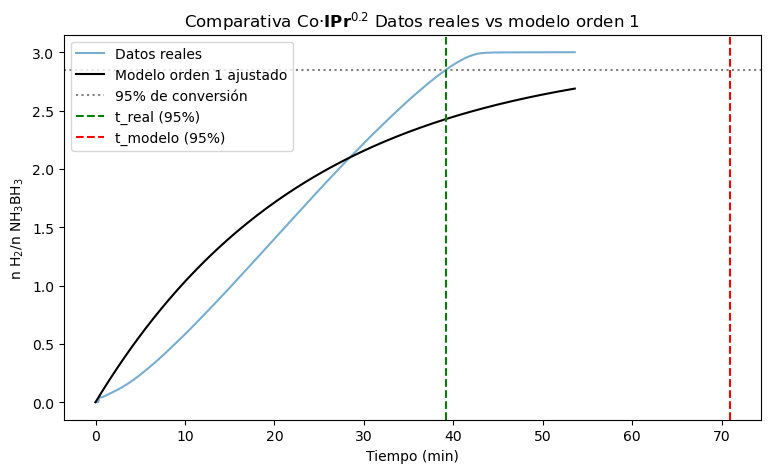

In [26]:
df_coipr = calcular_balance_materia("CoIPr0.2", archivo)
k1_coipr = resultados["CoIPr0.2"]["k1"] #Usamos el valor de k1 obtenida cuando ajustamos el modelo de orden 1 a CoIPr0.2
#Para la representación gráfica de una curva generada a partir de los datos del modelo, tomamos las variables t_continuo e y_modelo_continuo propias del catalizador CoIPR0.2
t_continuo = np.linspace(0, df_coipr["t(min)"].max(), 200) #Generamos 200 puntos espaciados a lo largo del rango medido, para gráficamente observar una curva suave y continua
y_modelo_continuo = modelo_orden1_fijo(t_continuo, k1_coipr)

plt.figure(figsize=(9, 5)) #Ajustamos la figura
plt.plot(df_coipr["t(min)"], df_coipr["nH2/nNH3BH3_norm"], label="Datos reales", alpha=0.6) #Ploteamos los df propios de los datos experimentales, de tiempo y equivalentes de hidrógeno generados, ya normalizados
plt.plot(t_continuo, y_modelo_continuo, color="black", linestyle="-", label="Modelo orden 1 ajustado") #Ploteamos los 200 puntos generados previamente para el modelo
plt.axhline(0.95 * 3.0, color="gray", linestyle=":", label="95% de conversión") #Generamos una línea horizontal para señalar la conversión del 95%
plt.axvline(39.170055, color="green", linestyle="--", label="t_real (95%)") #Generamos una línea vertical para señalar el tiempo correspondiente a los datos reales
plt.axvline(70.898283, color="red", linestyle="--", label="t_modelo (95%)") #Generamos una línea vertical para señalar el tiempo correspondiente a los datos del modelo
plt.xlabel("Tiempo (min)") #Etiquetamos eje X
plt.ylabel(r"n H$_2$/n NH$_3$BH$_3$") #Etiquetamos eje Y
plt.title(r'Comparativa Co·$\mathbf{IPr}^{0.2}$ Datos reales vs modelo orden 1') #Titulamos el gráfico
plt.legend() #Especificamos leyenda
plt.savefig("Comparativa_Datos realesvsmodelo_orden_1.png", dpi=300, bbox_inches="tight") #Guardamos los heatmaps imagen de manera local
plt.show() 

Esta gráfica muestra que el modelo de orden 1 sobreestima la actividad inicial, la velocidad de la reacción según el modelo comienza muy alta, y va aplanándose conforme avanza. Sin embargo, los datos reales muestran otra realidad, el arranque es más lento, la velocidad de la reacción se incrementa hacia la mitad, y la curva sólo se aplana hacia el final de la reacción. Sobre el minuto 30, ambas gráficas se cruzan, los datos reales adelantan lo predicho por el modelo de orden 1. Con esta comparación sobre la mesa, el modelo de orden 1 no resulta apropiado, al menos para el catalizador CoIPr0.2.  Comprobemos qué ocurre para el resto de catalizadores: 

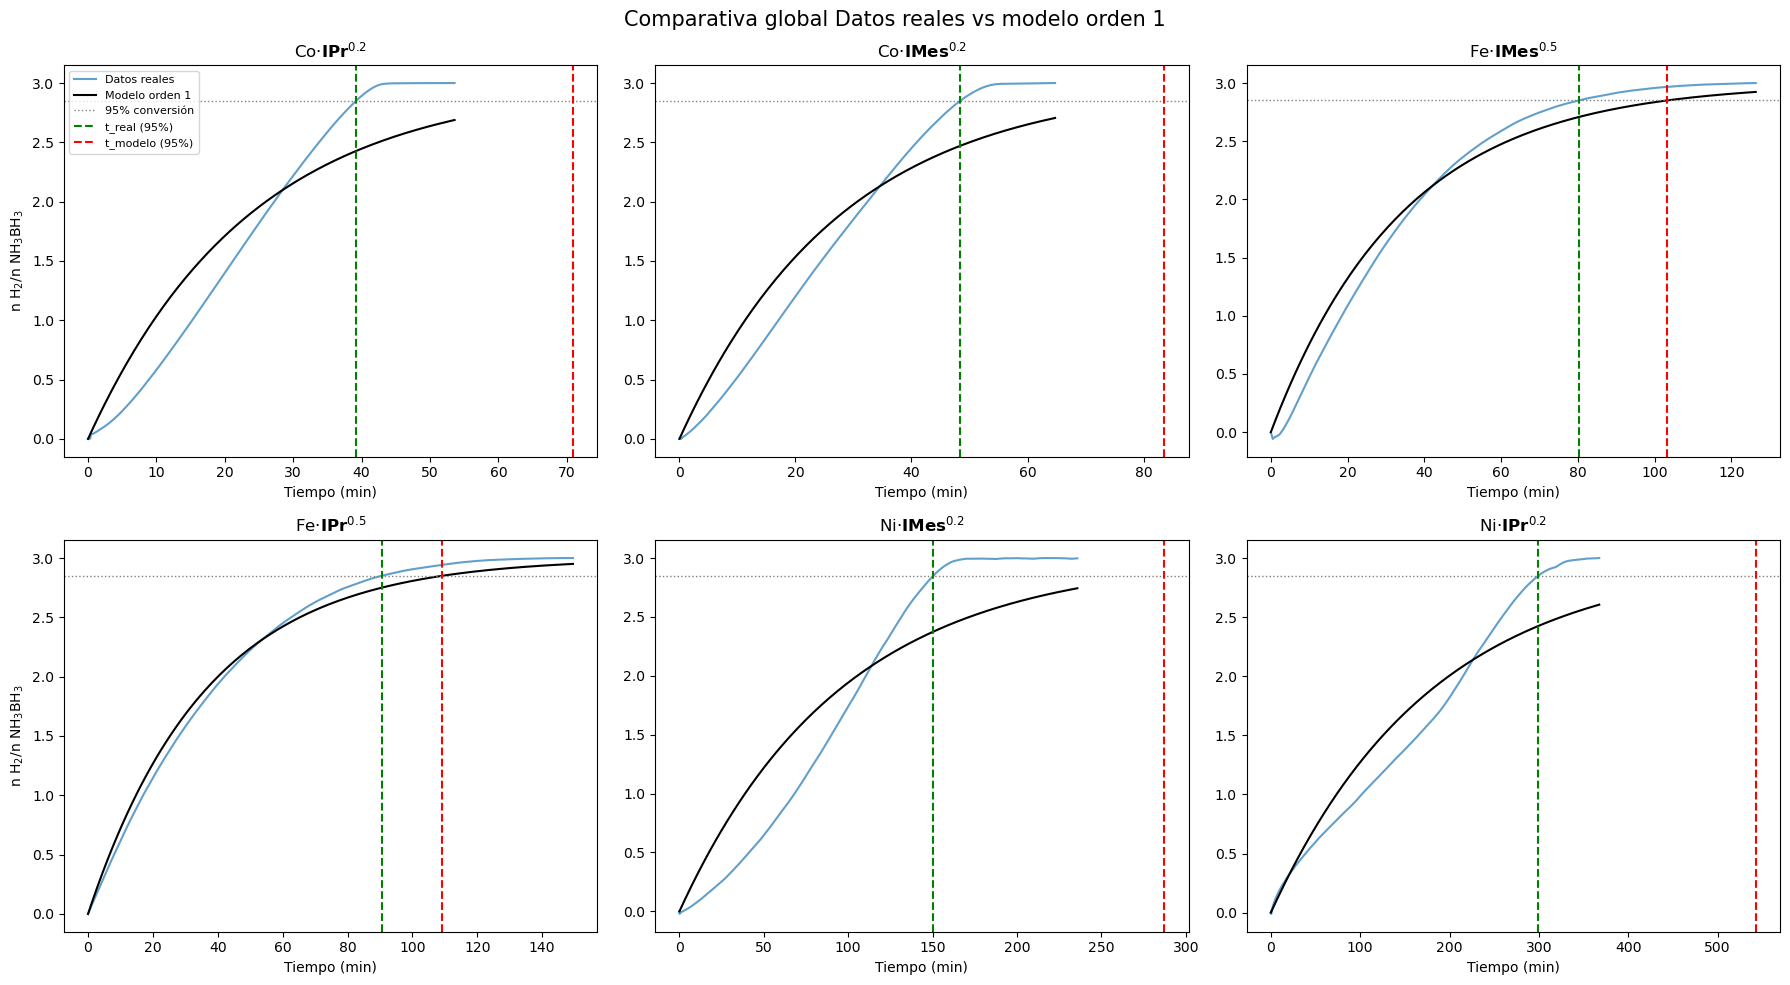

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, hoja in enumerate(orden_por_actividad):
    df_hoja = calcular_balance_materia(hoja, archivo)
    k1 = resultados[hoja]["k1"]

    t_continuo = np.linspace(0, df_hoja["t(min)"].max(), 200)
    y_modelo_continuo = modelo_orden1_fijo(t_continuo, k1)

    t_modelo_95 = -np.log(1 - 0.95) / k1
    t_real_95 = tiempo_real_para_conversion(df_hoja, 0.95)

    ax = axes[i]
    ax.plot(df_hoja["t(min)"], df_hoja["nH2/nNH3BH3_norm"], label="Datos reales", alpha=0.7)
    ax.plot(t_continuo, y_modelo_continuo, color="black", linestyle="-", label="Modelo orden 1")
    ax.axhline(0.95 * 3.0, color="gray", linestyle=":", linewidth=1, label="95% conversión")
    ax.axvline(t_real_95, color="green", linestyle="--", label="t_real (95%)")
    ax.axvline(t_modelo_95, color="red", linestyle="--", label="t_modelo (95%)")
    ax.set_title(etiquetas_catalizadores[hoja], fontsize=12)
    ax.set_xlabel("Tiempo (min)")
    if i == 0 or i == 3:
        ax.set_ylabel(r"n H$_2$/n NH$_3$BH$_3$")

axes[0].legend(fontsize=8)
plt.suptitle("Comparativa global Datos reales vs modelo orden 1", fontsize=15)
plt.tight_layout()
plt.savefig("comparacion_modelo_seis_catalizadores.png", dpi=300, bbox_inches="tight")
plt.show()


Con la información actualmente disponible, podemos destacar varios aspectos: 

1. Debido a las condiciones experimentales, tratar reacción como si fuera de pseudo-primer orden respecto al amina-borano tenía sentido como punto de partida.
2. Los datos de $R^2$ obtenidos tanto para el ajuste de orden 1 como de orden 2 mostraban que el de orden 1 sería más apropiado (a priori).
3. El modelo de orden 1 no se ajusta bien a los datos reales en el caso de los catalizadores de cobalto y níquel, por más que muestren valores aceptables de $R^2$, presenta errores relativos muy altos en lo que respecta a predecir el tiempo final de reacción. No se puede dar el modelo de orden 1 por válido para Co y Ni.
4. En el caso de los dos catalizadores de hierro, el resultado es diferente. Por un lado, los valores de $R^2$ fueron más altos. Por otro lado, el modelo se adapta mucho mejor a la forma de la curva real que en los casos de Co y Ni. Finalmente, el modelo predice el tiempo de reacción (para X = 0.95) con un error relativo del 28.52% (FeIMes0.5) y del 20.58% para (FeIPr0.5). En definitiva, aunque el modelo de orden 1 se ajusta mejor al caso del hierro, sigue presentando un error relativo muy alto.  
5. Habiendo descartado directamente en la introducción una cinética de orden 0 (que sería lineal), una cinética de orden 2 (por no obtener buenos valores de $R^2$) y por último, una cinética de primer orden, se pueden descartar por completo los ajustes a cinéticas simples. Debemos buscar modelos alternativos. 

La forma en "S" observada en los datos experimentales podría explicarse por una etapa de activación in situ del catalizador previa a alcanzar su máxima actividad catalítica. Los primeros modelos teóricos similares a dicho comportamiento autocatalítico se propusieron en los años noventa (Watzky & Finke, 1997), aunque aplicados a la formación de nuevas nanopartículas. En el caso de este notebook, se están tratando datos sobre nanopartículas que ya están presintetizadas y caracterizadas antes del experimento catalítico, por lo que el modelo de Watzky y Finke no resulta totalmente apropiado. Más recientemente, otros autores (Wunder *et al.*, 2011 y Neal *et al.*, 2019) han postulado que un nanocatalizador puede presentar un período de inducción debido a un reajuste superficial inducido por el sustrato. Esta hipótesis podría explicar el periodo de inducción observado, y tal vez aplicarla a nuestros datos arroje buenos resultados. En la siguiente celda vamos a explicar

### Modelo autocatalítico de dos etapas

A diferencia de los modelos de orden 0, 1 y 2 (que asumen un catalizador ya en su estado
catalíticamente activo desde $t=0$), el patrón en forma de S observado en varios catalizadores
sugiere una etapa de activación previa. Reutilizamos la ecuación matemática del mecanismo de
dos etapas de Watzky y Finke (1997) —originalmente descrito para la nucleación y crecimiento
autocatalítico de nanopartículas nuevas—, pero con una reinterpretación mecanística,
consistente con la hipótesis de reconstrucción/activación superficial de un catalizador ya
presintetizado (Wunder *et al.*, 2011 y Neal *et al.*, 2019): una etapa lenta de activación
(constante $k_1$) seguida de una etapa autocatalítica (constante $k_2$), donde el propio catalizador
activado acelera la activación del resto.

Trabajando directamente sobre la fracción de conversión observada $X(t)$ (de 0 a 1), la ecuación
diferencial de las dos etapas combinadas es:

$$\frac{dX}{dt} = k_1(1-X) + k_2(1-X)X$$

El primer término es la activación lenta (proporcional a lo que queda sin activar, $1-X$); el
segundo es la etapa autocatalítica (proporcional tanto a lo que queda por activar como a lo ya
activado, $X$ — de ahí que acelere a medida que $X$ crece, generando la forma en S).

Resolviendo esta ecuación diferencial con la condición inicial $X(0)=0$ (comprobado con álgebra
simbólica mediante Claude):

$$X(t) = \frac{k_1\left(e^{(k_1+k_2)t}-1\right)}{k_1 e^{(k_1+k_2)t}+k_2}$$

Y, como ya hicimos para el modelo de orden 1, traducimos a la magnitud de referencia, es decir, la formación de 3 equiv. de hidrógeno por mol de sustrato:

$$\frac{n_{H_2}}{n_{NH_3BH_3}}(t) = n_{max}\cdot X(t)$$

Veamos si los límites tienen sentido:
- $X(0) = \dfrac{k_1(1-1)}{k_1+k_2} = 0$ — sin activación al principio, correcto.
- $X(\infty) = \dfrac{k_1 \cdot \infty}{k_1 \cdot \infty} \to 1$ — conversión completa a tiempos largos, correcto.

A diferencia de $k_1$ en el modelo de orden 1 simple (una única constante con significado directo),
aquí $k_1$ y $k_2$ representan procesos distintos: $k_1$ la velocidad de activación "espontánea"
(no autocatalítica) del catalizador, y $k_2$ la contribución autocatalítica — cuanto mayor sea
$k_2$ frente a $k_1$, más pronunciada será la forma en S de la curva. Esta deducción asume que $\frac{n_{H_2}}{n_{NH_3BH_3}}(t)$ refleja la fracción de catalizador activado, por lo que se trata de una simplificación. Sin embargo, supone una suposición estándar para sistemas en los que no se puede medir directamente la fracción de catalizador activado de manera separada, como en este caso, donde medimos hidrógeno generado. Vamos a definir funciones en Python para por un lado, establecer la función modelo, y por otro modelar los datos que tenemos.

In [28]:
def modelo_autocatalitico(t, k1, k2): #Definimos la función utilizada para este modelo, utilizando como argumento el tiempo, k1, de la etapa lenta, y k2, de la etapa autocatalítica
    exponente = (k1 + k2) * t
    return 3.0 * (k1 * (np.exp(exponente) - 1)) / (k1 * np.exp(exponente) + k2) #Fijamos desde un principio el límite en 3, el máximo de equiv. de H2 generado

def ajuste_y_evaluacion_autocatalitico(t_datos, y_datos): 
    popt, pcov = curve_fit(modelo_autocatalitico, t_datos, y_datos, p0=[0.01, 0.05], #Empezamos con k1 más pequeño(empezamos en 0.01) que k2 (empezamos en 0.05) porque a nivel conceptual y químico esperamos que la etapa lenta sea más lenta que la etapa autocatalítica
                            method='trf', bounds=([0, 0], [0.5, 0.5])) #Con estos límites, si el tiempo máximo para el catalizador menos activo es 400 min, el exponente máximo será 1.0*400= 400, por debajo del límite donde np.exp() puede saturarse
    k1_autocatalitico, k2_autocatalitico = popt
    y_pred = modelo_autocatalitico(t_datos, k1_autocatalitico, k2_autocatalitico)
    r2 = calcular_r2(y_datos, y_pred)
    return k1_autocatalitico, k2_autocatalitico, r2

In [29]:
A0_molar = 1.9  # mol/L
resultados_autocatalitico = {}
for hoja in orden_por_actividad:
    df_hoja = calcular_balance_materia(hoja, archivo)
    t_datos_hoja = df_hoja["t(min)"].to_numpy() #Como otras veces, utilizamos la columna t(min) del df creado inicialmente
    y_datos_hoja = df_hoja["nH2/nNH3BH3_norm"].to_numpy() #Asignamos directamente los valores normalizados de equiv. de hidrógeno generados

    k1_autocatalitico, k2_autocatalitico, r2_autocatalitico = ajuste_y_evaluacion_autocatalitico(t_datos_hoja, y_datos_hoja) #Usamos la función definida en la celda anterior con las columnas t(min) y nH2/nNH3BH3_norm 
    r2_orden1 = resultados[hoja]["R2_orden1"] #Dejamos a mano los resultados de la correlación de orden 1 obtenidos anteriormente para utilizarlos en una comparativa con el modelo autocatalitico nuevo

    resultados_autocatalitico[hoja] = {"k1_autocatalitico": k1_autocatalitico, "k2_autocatalitico": k2_autocatalitico, "R2_autocatalitico": r2_autocatalitico} #Almacenamos estos resultados en un diccionario
    resultados_autocatalitico[hoja]["k2_autocatalitico_real"] = resultados_autocatalitico[hoja]["k2_autocatalitico"] / A0_molar #Hacemos la misma corrección que se hico anteriormente cuando se ajustó a un modelo cinético de orden 2
    print(hoja, " | k1=", round(k1_autocatalitico, 4), #Imprimimos en pantalla todo
      " | k2=", round(k2_autocatalitico, 4),
      " | modelo_autocatalitico R²=", round(r2_autocatalitico, 3), #Vemos el valor de R^2 en el caso del nuevo modelo que hemos definido
      " | orden1 R²=", round(r2_orden1, 3), #Imprimimos de nuevo el valor de R^2 para el modelo de orden 1 estudiado previamente
      " | diferencia=", round(r2_autocatalitico - r2_orden1, 3), #Calculamos la diferencia entre ambos R^2
" | k2_real=", round(resultados_autocatalitico[hoja]["k2_autocatalitico_real"], 4)) #Imprimimos también el k2_autocatalitico real, para mostrarlo de cara a posibles comparaciones bibliográficas. No es necesario de cara a ajuste del modelo. 

CoIPr0.2  | k1= 0.0103  | k2= 0.113  | modelo_autocatalitico R²= 0.994  | orden1 R²= 0.893  | diferencia= 0.102  | k2_real= 0.0595
CoIMES0.2  | k1= 0.0108  | k2= 0.0833  | modelo_autocatalitico R²= 0.995  | orden1 R²= 0.911  | diferencia= 0.083  | k2_real= 0.0438
FeIMes0.5  | k1= 0.0155  | k2= 0.037  | modelo_autocatalitico R²= 0.999  | orden1 R²= 0.971  | diferencia= 0.028  | k2_real= 0.0195
FeIPr0.5  | k1= 0.0198  | k2= 0.0187  | modelo_autocatalitico R²= 0.999  | orden1 R²= 0.99  | diferencia= 0.009  | k2_real= 0.0098
NiIMes0.2  | k1= 0.0017  | k2= 0.034  | modelo_autocatalitico R²= 0.995  | orden1 R²= 0.868  | diferencia= 0.127  | k2_real= 0.0179
NiIPr0.2  | k1= 0.0021  | k2= 0.0109  | modelo_autocatalitico R²= 0.974  | orden1 R²= 0.906  | diferencia= 0.068  | k2_real= 0.0058


Buenas noticias. Con los resultados anteriores, podemos extraer varias conclusiones. Si ajustamos los datos a un modelo autocatalítico en dos etapas, consistentemente el $R^2$ es muy alto, por encima de $R^2$=0.97 en todos los casos. En comparación con el obtenido para el modelo de orden 1, es un resultado mucho mejor. Por otro lado, los valores de k2 muestran que en la práctica totalidad de los casos (con una excepción) la etapa autocatalítica domina sobre la lenta. Cuantifiquémoslo en la siguiente celda.

In [30]:
filas_ratio = [] #Creamos una lista que incluya los valores de k1_autocatalitico y k2_autocatalitico y el cociente k2/k1
for hoja in orden_por_actividad:
    k1_ac = resultados_autocatalitico[hoja]["k1_autocatalitico"] #Asignamos los resultados "k1_autocatalitico" a la variable k1_ac
    k2_ac = resultados_autocatalitico[hoja]["k2_autocatalitico"] #Idem con los resultados "k2_autocatalitico" 
    filas_ratio.append({ #Definimos el diccionario que incluya los valores anteriores así como los nombres de cada columna como keys 
        "Catalizador": hoja,
        "k1_autocatalitico": k1_ac,
        "k2_autocatalitico": k2_ac,
        "k2/k1": k2_ac / k1_ac
    })

tabla_ratio_autocatalitico = pd.DataFrame(filas_ratio).set_index("Catalizador") #Convertimos el diccionario filas_ratio en un df de pandas
tabla_ratio_autocatalitico = tabla_ratio_autocatalitico.sort_values("k2/k1", ascending=False) #Ordenamos los resultados de mayor a menor cociente k2/k1 
print(tabla_ratio_autocatalitico) #Visualizamos

             k1_autocatalitico  k2_autocatalitico      k2/k1
Catalizador                                                 
NiIMes0.2             0.001652           0.034038  20.610180
CoIPr0.2              0.010343           0.112975  10.922298
CoIMES0.2             0.010843           0.083310   7.683096
NiIPr0.2              0.002115           0.010927   5.166823
FeIMes0.5             0.015530           0.036976   2.380886
FeIPr0.5              0.019838           0.018689   0.942046


Con la tabla anterior, el orden por metal es explícito y cuantificable. Ni y Co muestran cocientes k2/k1 de un orden de magnitud (20-5), mientras que Fe se queda en 2.4 o incluso 0.94. Es decir, en el caso de FeIPr0.5, la etapa autocatalítica no domina sobre la lenta. Esto cuadra con ser el catalizador que menos diferencia mostraba entre los $R^2$ obtenidos para el modelo de orden 1 y el modelo autocatalitico. A continuación, la "prueba del algodón", observar si este nuevo modelo predice mejor los tiempos a los que se alcanzarán distintos valores de conversión. Comencemos obteniendo el error relativo en cada caso, respecto a los datos reales. 

In [31]:
def t_conversion_autocatalitico(fraccion, k1_ac, k2_ac): #Definimos una función con tres parámetros de entrada, el grado de conversión buscado, y las k1_autocatalitico y k2_autocatalitico 
    return np.log((k1_ac + fraccion * k2_ac) / (k1_ac * (1 - fraccion))) / (k1_ac + k2_ac) #np.log( ... / ... ) es el logaritmo neperiano en Numpy. Del modelo autocatalítico en dos etapas que hemos tratado anteriormente, k1_ac + fraccion * k2_ac es el numerador dentro del logaritmo, el denominador sería (k1_ac * (1 - fraccion). Finalmente, (k1_ac + k2_ac) divide todo el resultado del logaritmo entre (k1 + k2), tal y como decía la fórmula. 

filas_autocatalitico = []
for hoja in orden_por_actividad:
    df_hoja = calcular_balance_materia(hoja, archivo)
    k1_ac = resultados_autocatalitico[hoja]["k1_autocatalitico"]
    k2_ac = resultados_autocatalitico[hoja]["k2_autocatalitico"]

    for fraccion in fracciones_objetivo:
        t_modelo_ac = t_conversion_autocatalitico(fraccion, k1_ac, k2_ac)
        t_real = tiempo_real_para_conversion(df_hoja, fraccion) #Reutilizamos tiempo_real_para_conversion y fracciones_objetivo, que definimos anteriormente
        error_abs = t_modelo_ac - t_real
        error_rel = error_abs / t_real * 100
        filas_autocatalitico.append({
            "Catalizador": hoja,
            "Conversion": f"{int(fraccion*100)}%",
            "t_modelo_autocatalitico_min": t_modelo_ac,
            "t_real_min": t_real,
            "error_rel_%": error_rel
        })

tabla_comparativa_autocatalitico = pd.DataFrame(filas_autocatalitico)
print(tabla_comparativa_autocatalitico)

   Catalizador Conversion  t_modelo_autocatalitico_min  t_real_min  \
0     CoIPr0.2        90%                    37.990425   36.670052   
1     CoIPr0.2        95%                    44.010158   39.170055   
2     CoIPr0.2        99%                    57.366846   42.003392   
3    CoIMES0.2        90%                    46.427819   44.836730   
4    CoIMES0.2        95%                    54.293128   48.420068   
5    CoIMES0.2        99%                    71.773194   52.753407   
6    FeIMes0.5        90%                    65.663052   66.434760   
7    FeIMes0.5        95%                    79.572455   80.268112   
8    FeIMes0.5        99%                   110.773068  104.601480   
9     FeIPr0.5        90%                    75.702974   75.250106   
10    FeIPr0.5        95%                    94.347545   90.500126   
11    FeIPr0.5        99%                   136.632983  117.583498   
12   NiIMes0.2        90%                   147.816100  141.334336   
13   NiIMes0.2      

A priori, ya se puede observar que el error relativo cometido por el modelo autocatalítico respecto a los datos reales es muy inferior al cometido por el modelo de orden 1. Sin embargo, vamos a realizar también una comparativa visual, para los seis catalizadores y grado de conversión 0.95; y comprobar de paso si de verdad el modelo autocatalítico se ajusta bien a la forma de la curva. 

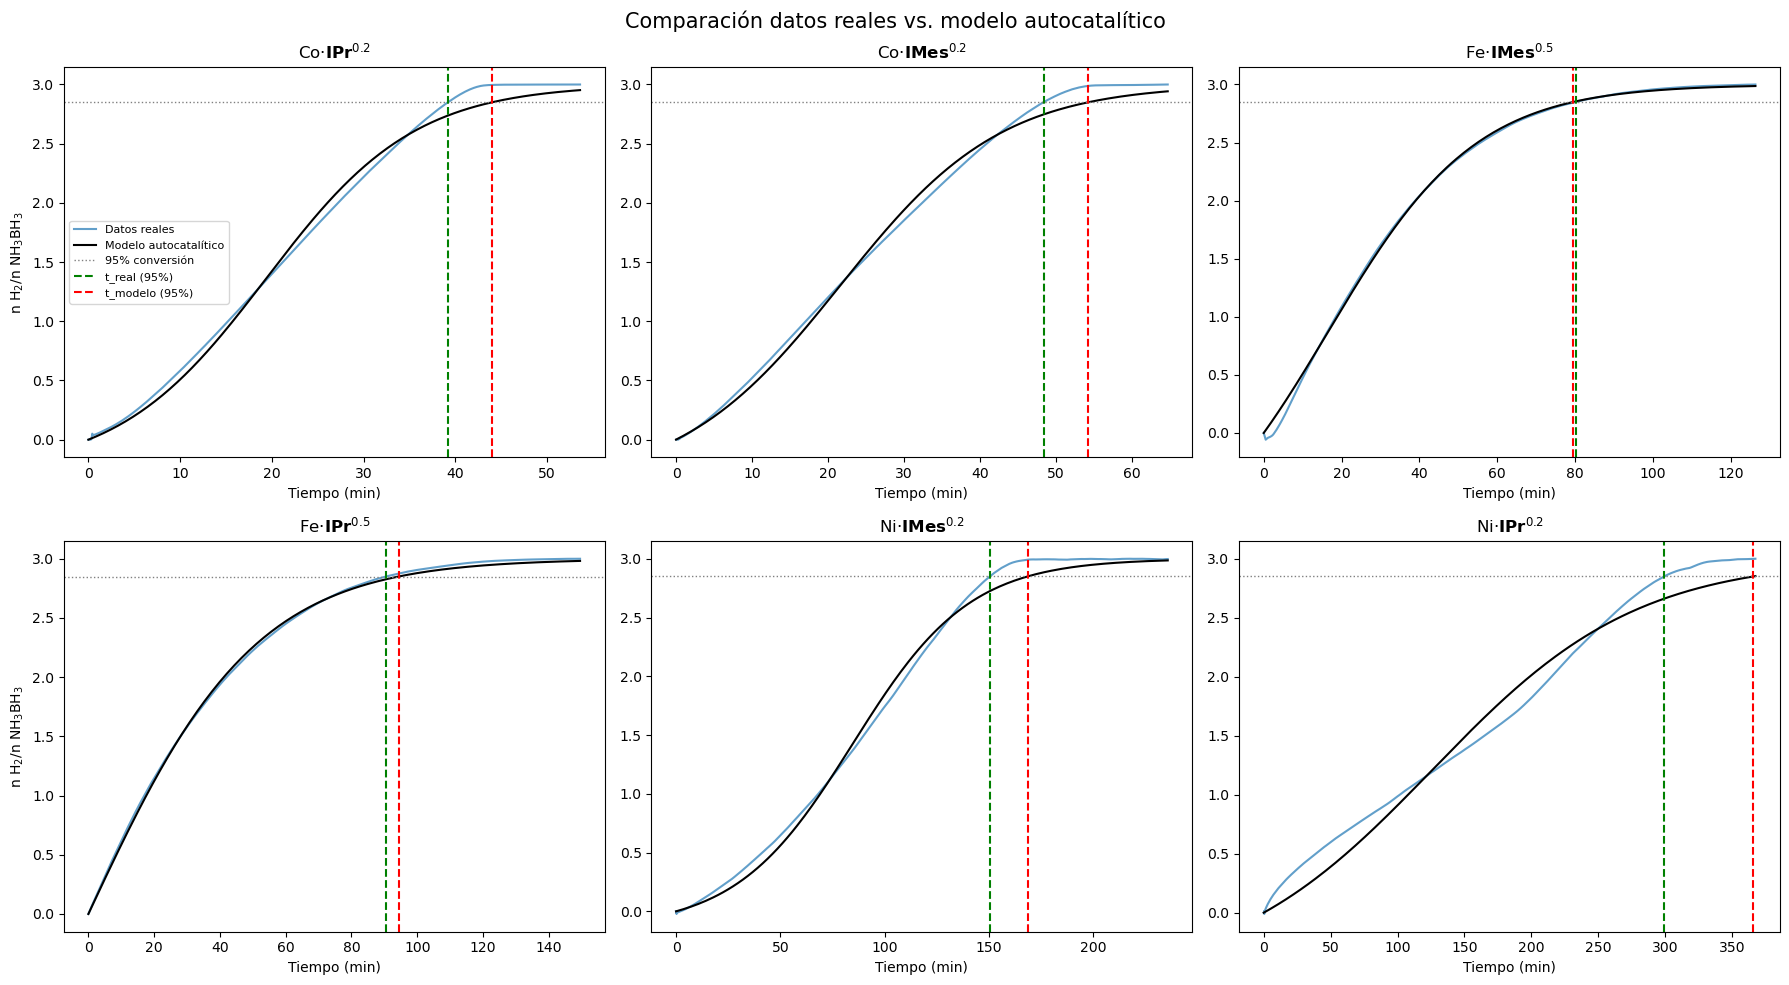

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, hoja in enumerate(orden_por_actividad):
    df_hoja = calcular_balance_materia(hoja, archivo)
    k1_ac = resultados_autocatalitico[hoja]["k1_autocatalitico"]
    k2_ac = resultados_autocatalitico[hoja]["k2_autocatalitico"]

    t_continuo = np.linspace(0, df_hoja["t(min)"].max(), 200)
    y_modelo_continuo = modelo_autocatalitico(t_continuo, k1_ac, k2_ac)

    t_modelo_95 = t_conversion_autocatalitico(0.95, k1_ac, k2_ac)
    t_real_95 = tiempo_real_para_conversion(df_hoja, 0.95)

    ax = axes[i]
    ax.plot(df_hoja["t(min)"], df_hoja["nH2/nNH3BH3_norm"], label="Datos reales", alpha=0.7)
    ax.plot(t_continuo, y_modelo_continuo, color="black", linestyle="-", label="Modelo autocatalítico")
    ax.axhline(0.95 * 3.0, color="gray", linestyle=":", linewidth=1, label="95% conversión")
    ax.axvline(t_real_95, color="green", linestyle="--", label="t_real (95%)")
    ax.axvline(t_modelo_95, color="red", linestyle="--", label="t_modelo (95%)")
    ax.set_title(etiquetas_catalizadores[hoja], fontsize=12)
    ax.set_xlabel("Tiempo (min)")
    if i == 0 or i == 3:
        ax.set_ylabel(r"n H$_2$/n NH$_3$BH$_3$")

axes[0].legend(fontsize=8)
plt.suptitle("Comparación datos reales vs. modelo autocatalítico", fontsize=15)
plt.tight_layout()
plt.savefig("comparacion_modelo_autocatalitico_seis_catalizadores.png", dpi=300, bbox_inches="tight")
plt.show()

La gráfica que hemos llamado "Comparación datos reales vs. modelo autocatalítico" Indica visualmente de manera muy clara cómo el modelo autocatalítico es mucho más adecuado para los datos experimentales que tenemos. No sólo el error a la hora de determinar tiempos finales de reacción respecto a datos reales es mucho menor, sino que la curva modelada se ajusta bastante bien a los datos experimentales disponibles. Un caso particular es el catalizador NiIPr0.2, que tiene un comportamiento un tanto más errático, tanto en lo que respecta a ajuste a la curva como a tiempo de reacción predicho.  

Vamos a finalizar este proyecto realizando un heatamp que sirva para establecer una comparativa entre los dos principales modelos cinéticos que hemos analizado, el de orden 1 y el autocatalítico. 

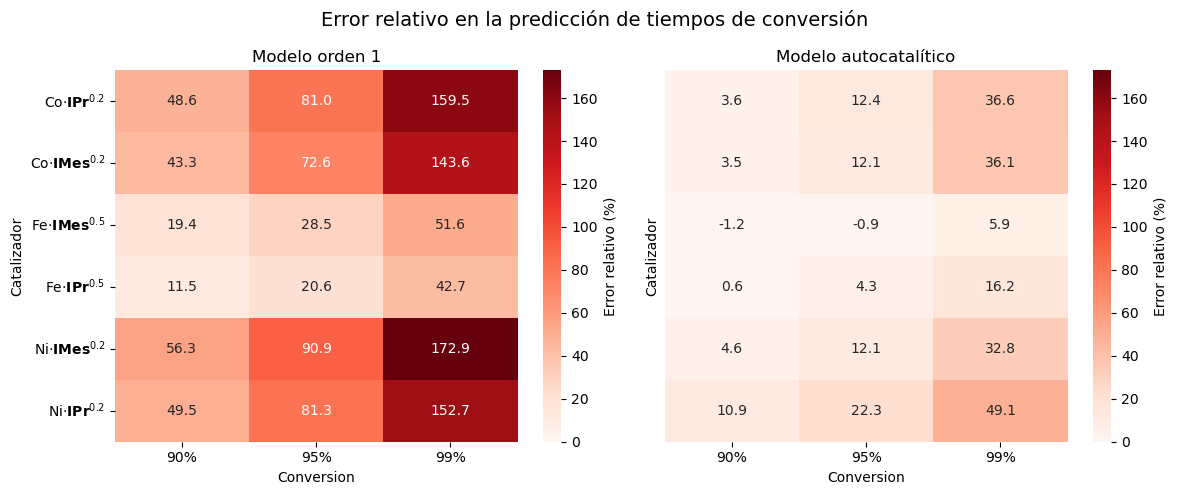

In [33]:
import seaborn as sns #Importamos seaborn, importante, abreviamos como sns
tabla_final_comparativa = tabla_comparativa[["Catalizador", "Conversion", "error_rel_%"]].rename(
    columns={"error_rel_%": "error_orden1_%"} #Utilizamos los datos de las columnas pertenecientes a la tabla comparativa creada inicialmente 
)
tabla_final_comparativa["error_autocatalitico_%"] = tabla_comparativa_autocatalitico["error_rel_%"]

pivot_orden1 = tabla_final_comparativa.pivot(index="Catalizador", columns="Conversion", values="error_orden1_%") #Extraemos los datos de error del modelo de orden 1. Convertimos una tabla alargada, de 18 filas, en una achatada, con los catalizadores en filas, los niveles de conversión en colúmnas y el error relativo dentro de cada celdilla. Formato adecuado para sns.heatmap(), de 6x3
pivot_orden1 = pivot_orden1.reindex(orden_por_actividad)[["90%", "95%", "99%"]] #Con .pivot dejaríamos las filas ordenadas alfabéticamente. Con esta línea de código las ordenamos por orden de actividad, tiene más sentido científico. También, forzamos el orden de los valores de conversión, en %

pivot_autocatalitico = tabla_final_comparativa.pivot(index="Catalizador", columns="Conversion", values="error_autocatalitico_%") #Ídem a lo anterior, con los datos de error relativo del modelo autocatalítico.
pivot_autocatalitico = pivot_autocatalitico.reindex(orden_por_actividad)[["90%", "95%", "99%"]]

vmax_comun = max(pivot_orden1.max().max(), pivot_autocatalitico.max().max()) # pivot_orden1.max(), calcula el máximo de cada columna por separado, devolviendo una serie con tres valores (el máximo de la columna 90%, el de 95%, el de 99%). Además, .max() otra vez encadenado da un único número: el máximo de los tres, que coincide con el máximo de toda la tabla. Finalmente, el max(...) de Python (la función normal, no el método de pandas) compara ese máximo global de pivot_orden1 contra el de pivot_autocatalitico, y se queda con el mayor de los dos. Como orden 1 tiene errores mucho más altos (hasta 56%), este número va a ser el máximo de la tabla.

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) #1 fila, 2 columnas de "huecos" para gráficos. Además, ajustamos figsize.

sns.heatmap(pivot_orden1, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=vmax_comun,
            ax=axes[0], yticklabels=[etiquetas_catalizadores[c] for c in orden_por_actividad],
            cbar_kws={'label': 'Error relativo (%)'})
axes[0].set_title("Modelo orden 1")

sns.heatmap(pivot_autocatalitico, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=vmax_comun, #Ídem al bloque anterior
            ax=axes[1], yticklabels=False,
            cbar_kws={'label': 'Error relativo (%)'})
axes[1].set_title("Modelo autocatalítico")

plt.suptitle("Error relativo en la predicción de tiempos de conversión", fontsize=14) #Titulamos la comparativa
plt.tight_layout()
plt.savefig("comparacion_errores_heatmap.png", dpi=300, bbox_inches="tight") #Guardamos el fichero
plt.show()

Con este heatmap de seaborn, en la que visualizamos los errores relativos encontrados para cada modelo, podemos dar por finalizado este proyecto. A modo de resumen, se puede destacar que en este notebook se han modelado datos experimentales de acuerdo a tres funciones matemáticas. Por una parte, a cinéticas de orden uno y de orden dos, y por otro lado, a un modelo autocatalítico. Este último ha resultado ser mucho más preciosa, tanto en lo que respecta a ajuste a la forma de la curva de los datos experimentales, como en el error relativo encontrado al utilizarlo para predecir tiempos de reacción para distinta conversión.   

1. Perrin, C. L. *Linear or Nonlinear Least-Squares Analysis of Kinetic Data?* J. Chem. Educ.
  **2017**, 94, 669–672. [https://doi.org/10.1021/acs.jchemed.6b00629](https://doi.org/10.1021/acs.jchemed.6b00629)
  — Análisis de datos cinéticos  de primer y segundo orden.

2. Bravenec, A. D.; Ward, K. D. *Interactive Python Notebooks for Physical Chemistry.* J. Chem. Educ.
  **2023**, 100, 933–940. [https://doi.org/10.1021/acs.jchemed.2c00665](https://doi.org/10.1021/acs.jchemed.2c00665)
  — Diseño de notebooks de Python/Jupyter diseñados para mostrar cinética de orden cero y primer orden
  (Tiempo de semirreacción, efecto de la constante de velocidad), enfoque similar al de este proyecto.

3. Watzky, M. A.; Finke, R. G. *Transition Metal Nanocluster Formation Kinetic and Mechanistic
  Studies. A New Mechanism When Hydrogen Is the Reductant: Slow, Continuous Nucleation and Fast
  Autocatalytic Surface Growth.* J. Am. Chem. Soc. **1997**, 119, 10382–10400.
  [https://doi.org/10.1021/ja9705102](https://doi.org/10.1021/ja9705102) — Primera publicación sobre la formación de nanopartículas metálicas según un mecanismo de dos etapas.

4. Wunder, S.; Lu, Y.; Albrecht, M.; Ballauff, M. *Catalytic Activity of Faceted Gold Nanoparticles
  Studied by a Model Reaction: Evidence for Substrate-Induced Surface Restructuring.* ACS Catal.
  **2011**, 1, 908–916. [https://doi.org/10.1021/cs200208a](https://doi.org/10.1021/cs200208a) — Paper construido alrededor de la hipótesis de que un nanocatalizador puede presentar un período de inducción debido a un reajuste superficial inducido por el sustrato. 

5. Neal, R. D.; Inoue, Y.; Hughes, R. A.; Neretina, S. *Catalytic Reduction of 4-Nitrophenol by Gold
  Catalysts: The Influence of Borohydride Concentration on the Induction Time.* J. Phys. Chem. C
  **2019**, 123, 12894–12901. [https://doi.org/10.1021/acs.jpcc.9b02396](https://doi.org/10.1021/acs.jpcc.9b02396)
  — review donde se debate el origen del periodo de inducción en catálisis con nanopartículas metálicas sintetizadas previamente.

6. Molinillo Fernández, P. *Metal nanoparticles (Fe, Co, Ni, Ru) stabilised by SNS and NHC ligands. Synthesis, Characterisation and Catalytic Applications.* Tesis Doctoral, Universidad de Sevilla, **2025**. [https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b](https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b)— Capítulo IV: metanólisis de amina-borano catalizada por nanopartículas de Fe, Co y Ni, fuente original de los datos usados en este notebook.